In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import pickle
import os

# ── Load Phase 2 output ────────────────────────────────────────────────
df = pd.read_parquet("give the path to df_2019_features.parquet here")
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df = df.sort_values("tpep_pickup_datetime").reset_index(drop=True)

print(f"Loaded: {df.shape}")
print(f"Date range: {df['tpep_pickup_datetime'].min()} → {df['tpep_pickup_datetime'].max()}")

FEATURES = [
    "trip_distance", "passenger_count",
    "pickup_hour", "pickup_dow", "pickup_month",
    "is_rush_hour", "is_night", "is_weekend", "season",
    "PULocationID", "DOLocationID",
    "is_airport_trip", "same_zone",
    "pu_zone_type_enc", "do_zone_type_enc",
    "rate_type_enc", "store_and_fwd_flag_enc", "VendorID"
]
TARGET = "trip_duration"

X = df[FEATURES]
y = df[TARGET]

Loaded: (688382, 21)
Date range: 2009-01-01 00:16:03 → 2033-04-27 12:41:35


In [2]:
# ── SECTION 1: Walk-Forward Validation ────────────────────────────────
# Split 2019 by month — train on earlier months, test on later months
# This simulates real deployment: model trained on past, evaluated on future

months = sorted(df["pickup_month"].unique())
print(f"Months available: {months}")

# We need at least 2 months to start — train on month 1, test on month 2 onwards
results = []

for test_month in months[1:]:  # start from month 2
    train_months = [m for m in months if m < test_month]
    
    train_mask = df["pickup_month"].isin(train_months)
    test_mask  = df["pickup_month"] == test_month
    
    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]
    
    # ── Linear Regression ──
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_preds = lr.predict(X_test)
    
    lr_mae  = mean_absolute_error(y_test, lr_preds)
    lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
    lr_mape = np.mean(np.abs((y_test - lr_preds) / y_test)) * 100
    
    # ── XGBoost ──
    xgb = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb.fit(X_train, y_train)
    xgb_preds = xgb.predict(X_test)
    
    xgb_mae  = mean_absolute_error(y_test, xgb_preds)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
    xgb_mape = np.mean(np.abs((y_test - xgb_preds) / y_test)) * 100
    
    results.append({
        "test_month":    test_month,
        "train_months":  len(train_months),
        "test_size":     len(X_test),
        "lr_mae":        round(lr_mae,  4),
        "lr_rmse":       round(lr_rmse, 4),
        "lr_mape":       round(lr_mape, 4),
        "xgb_mae":       round(xgb_mae,  4),
        "xgb_rmse":      round(xgb_rmse, 4),
        "xgb_mape":      round(xgb_mape, 4),
    })
    
    print(f"Month {test_month:02d} | Train: {len(train_months)} months | "
          f"LR MAE: {lr_mae:.2f} | XGB MAE: {xgb_mae:.2f}")

results_df = pd.DataFrame(results)
print("\nFull results:")
print(results_df.to_string(index=False))

Months available: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Month 02 | Train: 1 months | LR MAE: 4.08 | XGB MAE: 2.80
Month 03 | Train: 2 months | LR MAE: 4.39 | XGB MAE: 2.87
Month 04 | Train: 3 months | LR MAE: 4.53 | XGB MAE: 3.00
Month 05 | Train: 4 months | LR MAE: 4.86 | XGB MAE: 3.23
Month 06 | Train: 5 months | LR MAE: 4.86 | XGB MAE: 3.22
Month 07 | Train: 6 months | LR MAE: 4.77 | XGB MAE: 3.34
Month 08 | Train: 7 months | LR MAE: 1.93 | XGB MAE: 0.97
Month 09 | Train: 8 months | LR MAE: 5.01 | XGB MAE: 3.39
Month 10 | Train: 9 months | LR MAE: 4.95 | XGB MAE: 3.33
Month 11 | Train: 10 months | LR MAE: 3.16 | XGB MAE: 3.25
Month 12 | Train: 11 months | LR MAE: 5.09 | XGB MAE: 3.53

Full results:
 test_month  train_months  test_size  lr_mae  lr_rmse  lr_mape  xgb_mae  xgb_rmse  xgb_mape
          2             1      68039  4.0822   6.0071  41.1545   2.7975    

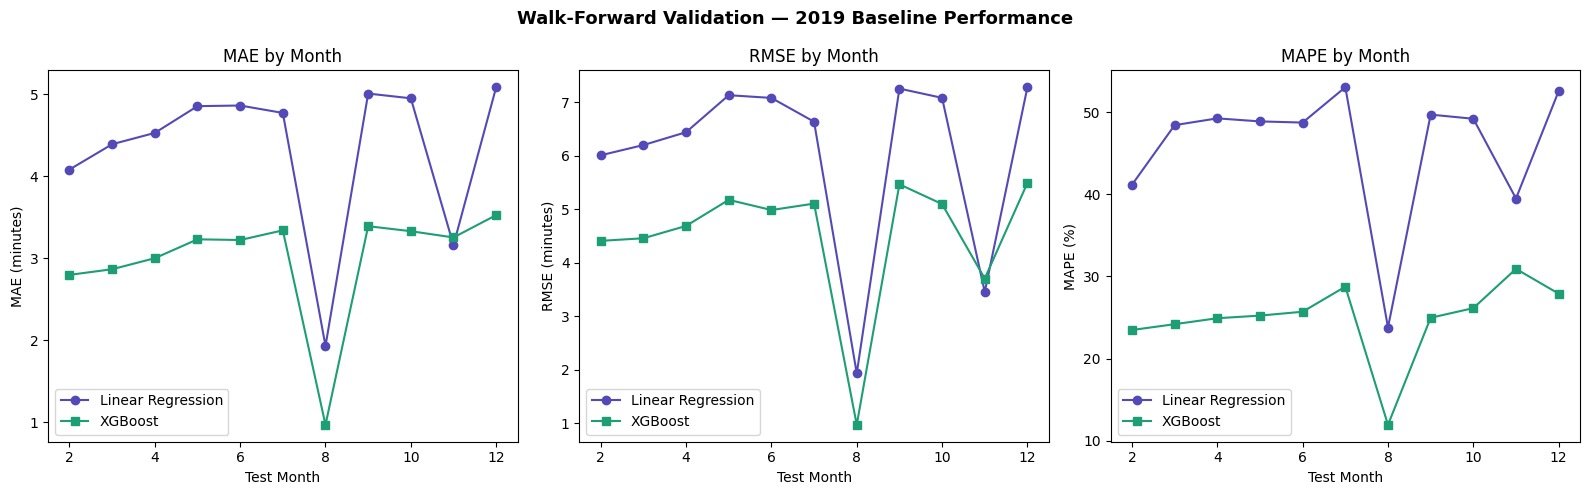

✓ Saved: walk_forward_results.png


In [ ]:
# ── SECTION 2: Results Visualisation ──────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Walk-Forward Validation — 2019 Baseline Performance",
             fontsize=13, fontweight="bold")

months_labels = results_df["test_month"].astype(str)

# MAE
axes[0].plot(results_df["test_month"], results_df["lr_mae"],
             marker="o", color="#534AB7", label="Linear Regression")
axes[0].plot(results_df["test_month"], results_df["xgb_mae"],
             marker="s", color="#1D9E75", label="XGBoost")
axes[0].set_title("MAE by Month")
axes[0].set_xlabel("Test Month")
axes[0].set_ylabel("MAE (minutes)")
axes[0].legend()

# RMSE
axes[1].plot(results_df["test_month"], results_df["lr_rmse"],
             marker="o", color="#534AB7", label="Linear Regression")
axes[1].plot(results_df["test_month"], results_df["xgb_rmse"],
             marker="s", color="#1D9E75", label="XGBoost")
axes[1].set_title("RMSE by Month")
axes[1].set_xlabel("Test Month")
axes[1].set_ylabel("RMSE (minutes)")
axes[1].legend()

# MAPE
axes[2].plot(results_df["test_month"], results_df["lr_mape"],
             marker="o", color="#534AB7", label="Linear Regression")
axes[2].plot(results_df["test_month"], results_df["xgb_mape"],
             marker="s", color="#1D9E75", label="XGBoost")
axes[2].set_title("MAPE by Month")
axes[2].set_xlabel("Test Month")
axes[2].set_ylabel("MAPE (%)")
axes[2].legend()

plt.tight_layout()
plt.savefig("give the path to save walk_forward_results.png here",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: walk_forward_results.png")

               feature  importance
         trip_distance    0.371442
       is_airport_trip    0.248166
              is_night    0.100537
      do_zone_type_enc    0.047968
             same_zone    0.042141
           pickup_hour    0.035101
          is_rush_hour    0.030662
         rate_type_enc    0.029595
            pickup_dow    0.022447
            is_weekend    0.021549
      pu_zone_type_enc    0.016216
          pickup_month    0.010566
          DOLocationID    0.008972
          PULocationID    0.006959
       passenger_count    0.002291
                season    0.001981
              VendorID    0.001796
store_and_fwd_flag_enc    0.001611


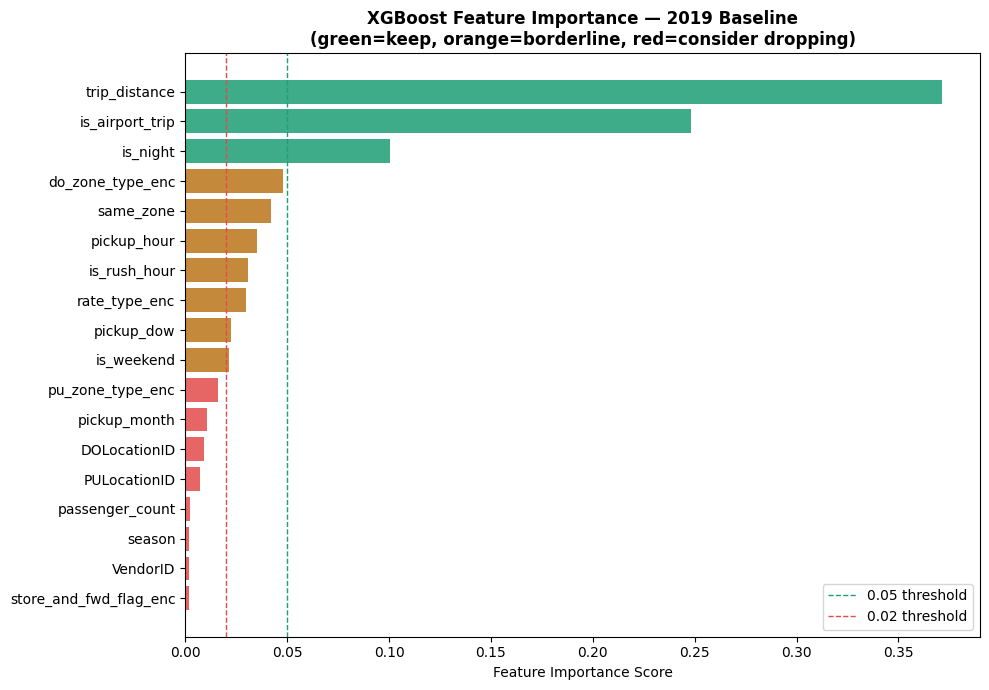

✓ Saved: feature_importance.png


In [ ]:
# ── SECTION 3: XGBoost Feature Importance ─────────────────────────────
# Train final XGBoost on ALL 2019 data for feature importance

xgb_final = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_final.fit(X, y)

importance_df = pd.DataFrame({
    "feature":    FEATURES,
    "importance": xgb_final.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 7))
colors = ["#1D9E75" if imp > 0.05 else "#BA7517" if imp > 0.02
          else "#E24B4A" for imp in importance_df["importance"]]
plt.barh(importance_df["feature"][::-1],
         importance_df["importance"][::-1],
         color=colors[::-1], alpha=0.85)
plt.xlabel("Feature Importance Score")
plt.title("XGBoost Feature Importance — 2019 Baseline\n"
          "(green=keep, orange=borderline, red=consider dropping)",
          fontweight="bold")
plt.axvline(0.05, color="#1D9E75", linestyle="--", linewidth=1, label="0.05 threshold")
plt.axvline(0.02, color="#E24B4A", linestyle="--", linewidth=1, label="0.02 threshold")
plt.legend()
plt.tight_layout()
plt.savefig("give the path to save feature_importance.png here",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: feature_importance.png")

In [ ]:
# ── SECTION 4: Save trained models ────────────────────────────────────

SAVE_PATH = "give the path to save models and results here"

# Train final LR on all 2019 data
lr_final = LinearRegression()
lr_final.fit(X, y)

# Save both models
with open(os.path.join(SAVE_PATH, "lr_2019_baseline.pkl"), "wb") as f:
    pickle.dump(lr_final, f)

with open(os.path.join(SAVE_PATH, "xgb_2019_baseline.pkl"), "wb") as f:
    pickle.dump(xgb_final, f)

# Save results
results_df.to_parquet(os.path.join(SAVE_PATH, "walk_forward_results_2019.parquet"), index=False)

print("✓ Saved: lr_2019_baseline.pkl")
print("✓ Saved: xgb_2019_baseline.pkl")
print("✓ Saved: walk_forward_results_2019.parquet")
print("\nPhase 3a complete. Ready for Phase 3b once 2020-2022 data is downloaded.")

✓ Saved: lr_2019_baseline.pkl
✓ Saved: xgb_2019_baseline.pkl
✓ Saved: walk_forward_results_2019.parquet

Phase 3a complete. Ready for Phase 3b once 2020-2022 data is downloaded.


In [ ]:
import os
import glob

base = "give the path to the directory containing 2020, 2021, and 2022 subdirectories here"

for year in ["2020", "2021", "2022"]:
    files = sorted(glob.glob(os.path.join(base, year, "*.parquet")))
    print(f"\n{year}: {len(files)} files")
    for f in files:
        size_mb = os.path.getsize(f) / 1024 / 1024
        print(f"  {os.path.basename(f)} — {size_mb:.1f} MB")


2020: 12 files
  yellow_tripdata_2020-01.parquet — 89.2 MB
  yellow_tripdata_2020-02.parquet — 87.9 MB
  yellow_tripdata_2020-03.parquet — 42.4 MB
  yellow_tripdata_2020-04.parquet — 4.2 MB
  yellow_tripdata_2020-05.parquet — 5.9 MB
  yellow_tripdata_2020-06.parquet — 9.1 MB
  yellow_tripdata_2020-07.parquet — 12.8 MB
  yellow_tripdata_2020-08.parquet — 15.8 MB
  yellow_tripdata_2020-09.parquet — 20.4 MB
  yellow_tripdata_2020-10.parquet — 25.1 MB
  yellow_tripdata_2020-11.parquet — 22.5 MB
  yellow_tripdata_2020-12.parquet — 22.0 MB

2021: 12 files
  yellow_tripdata_2021-01.parquet — 20.7 MB
  yellow_tripdata_2021-02.parquet — 20.8 MB
  yellow_tripdata_2021-03.parquet — 28.6 MB
  yellow_tripdata_2021-04.parquet — 32.4 MB
  yellow_tripdata_2021-05.parquet — 36.9 MB
  yellow_tripdata_2021-06.parquet — 42.0 MB
  yellow_tripdata_2021-07.parquet — 41.7 MB
  yellow_tripdata_2021-08.parquet — 41.4 MB
  yellow_tripdata_2021-09.parquet — 44.0 MB
  yellow_tripdata_2021-10.parquet — 50.8 MB
  y

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

BASE_PATH  = "give the path to the directory containing 2020, 2021, and 2022 subdirectories here"
BASE_PATH_1 = "give the path to the main project directory here"
SAVE_PATH  = os.path.join(BASE_PATH_1, "week3/")
SAMPLE_FRAC   = 0.01
RANDOM_STATE  = 42

FEATURES_FINAL = [
    "trip_distance", "is_airport_trip", "is_night",
    "do_zone_type_enc", "same_zone", "PULocationID", "DOLocationID",
    "pickup_hour", "is_rush_hour", "pickup_month",
    "pickup_dow", "is_weekend", "rate_type_enc", "pu_zone_type_enc",
]
TARGET = "trip_duration"

print("Setup complete")

Setup complete


In [11]:
# ── SECTION 1: Pipeline function ───────────────────────────────────────
# Single function that handles sampling + cleaning + feature engineering
# for any year — run it for 2020, 2021, 2022

import requests

# Download official TLC zone lookup
zone_df = pd.read_csv("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
AIRPORT_ZONES   = set(zone_df[zone_df["Zone"].str.contains("Airport", na=False)]["LocationID"])
MANHATTAN_ZONES = set(zone_df[zone_df["Borough"] == "Manhattan"]["LocationID"])

ratecode_map = {
    1.0: "standard", 2.0: "jfk", 3.0: "newark",
    4.0: "nassau_westchester", 5.0: "negotiated", 6.0: "group_ride"
}

def zone_type(zone_id):
    if zone_id in AIRPORT_ZONES:   return "airport"
    elif zone_id in MANHATTAN_ZONES: return "manhattan"
    else:                            return "outer"

def process_year(year_folder, year_label):
    files = sorted(glob.glob(os.path.join(BASE_PATH, year_folder, "*.parquet")))
    print(f"\n── Processing {year_label} ({len(files)} files) ──")

    samples = []
    for f in files:
        df = pd.read_parquet(f)
        month_label = os.path.basename(f).replace("yellow_tripdata_", "").replace(".parquet", "")

        # Parse datetime
        df["tpep_pickup_datetime"]  = pd.to_datetime(df["tpep_pickup_datetime"],  errors="coerce")
        df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

        # Derived columns needed for sampling + features
        df["pickup_hour"]    = df["tpep_pickup_datetime"].dt.hour
        df["pickup_dow"]     = df["tpep_pickup_datetime"].dt.dayofweek
        df["pickup_month"]   = df["tpep_pickup_datetime"].dt.month
        df["trip_duration"]  = (
            df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
        ).dt.total_seconds() / 60

        # Stratified sampling by hour
        sampled = (
            df.groupby("pickup_hour", group_keys=False)
              .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE),
                     include_groups=False)
        )
        sampled["pickup_hour"]  = df.loc[sampled.index, "pickup_hour"]
        sampled["month_label"]  = month_label
        samples.append(sampled)
        print(f"  {month_label}: {len(df):,} → {len(sampled):,} rows")

    df_year = pd.concat(samples).reset_index(drop=True)
    print(f"  Total sampled: {len(df_year):,} rows")

    # ── Cleaning ──
    df_year = df_year[
        (df_year["trip_duration"]  >= 1)  &
        (df_year["trip_duration"]  <= 120) &
        (df_year["trip_distance"]  >  0)  &
        (df_year["trip_distance"]  <= 50) &
        (df_year["fare_amount"]    >  0)  &
        (df_year["passenger_count"] >= 1) &
        (df_year["passenger_count"] <= 6)
    ].copy()
    print(f"  After cleaning: {len(df_year):,} rows")

    # ── Feature engineering ──
    df_year["is_rush_hour"]   = df_year["pickup_hour"].isin(list(range(7,10)) + list(range(16,20))).astype(int)
    df_year["is_night"]       = df_year["pickup_hour"].isin(list(range(22,24)) + list(range(0,6))).astype(int)
    df_year["is_weekend"]     = (df_year["pickup_dow"] >= 5).astype(int)

    df_year["pu_zone_type"]   = df_year["PULocationID"].apply(zone_type)
    df_year["do_zone_type"]   = df_year["DOLocationID"].apply(zone_type)
    df_year["is_airport_trip"]= (
        df_year["PULocationID"].isin(AIRPORT_ZONES) |
        df_year["DOLocationID"].isin(AIRPORT_ZONES)
    ).astype(int)
    df_year["same_zone"]      = (df_year["PULocationID"] == df_year["DOLocationID"]).astype(int)
    df_year["rate_type"]      = df_year["RatecodeID"].map(ratecode_map).fillna("unknown")

    # Encode categoricals
    zone_map  = {"airport": 0, "manhattan": 1, "outer": 2}
    rate_map  = {"standard": 0, "jfk": 1, "newark": 2,
                 "nassau_westchester": 3, "negotiated": 4, "group_ride": 5, "unknown": 6}

    df_year["pu_zone_type_enc"] = df_year["pu_zone_type"].map(zone_map).fillna(2).astype(int)
    df_year["do_zone_type_enc"] = df_year["do_zone_type"].map(zone_map).fillna(2).astype(int)
    df_year["rate_type_enc"]    = df_year["rate_type"].map(rate_map).fillna(6).astype(int)

    # Final null check
    X = df_year[FEATURES_FINAL]
    y = df_year[TARGET]
    print(f"  Null check — X: {X.isnull().sum().sum()} | y: {y.isnull().sum()}")

    return df_year

# ── Run for all 3 years ────────────────────────────────────────────────
df_2020 = process_year("2020", "2020")
df_2021 = process_year("2021", "2021")
df_2022 = process_year("2022", "2022")


── Processing 2020 (12 files) ──
  2020-01: 6,405,008 → 64,051 rows
  2020-02: 6,299,367 → 62,993 rows
  2020-03: 3,007,687 → 30,077 rows
  2020-04: 238,073 → 2,382 rows
  2020-05: 348,415 → 3,485 rows
  2020-06: 549,797 → 5,497 rows
  2020-07: 800,412 → 8,006 rows
  2020-08: 1,007,286 → 10,074 rows
  2020-09: 1,341,017 → 13,409 rows
  2020-10: 1,681,132 → 16,812 rows
  2020-11: 1,509,000 → 15,091 rows
  2020-12: 1,461,898 → 14,620 rows
  Total sampled: 246,497 rows
  After cleaning: 228,346 rows
  Null check — X: 0 | y: 0

── Processing 2021 (12 files) ──
  2021-01: 1,369,769 → 13,699 rows
  2021-02: 1,371,709 → 13,717 rows
  2021-03: 1,925,152 → 19,251 rows
  2021-04: 2,171,187 → 21,710 rows
  2021-05: 2,507,109 → 25,072 rows
  2021-06: 2,834,264 → 28,343 rows
  2021-07: 2,821,746 → 28,216 rows
  2021-08: 2,788,757 → 27,890 rows
  2021-09: 2,963,793 → 29,638 rows
  2021-10: 3,463,504 → 34,635 rows
  2021-11: 3,472,949 → 34,730 rows
  2021-12 (1): 3,214,369 → 32,145 rows
  Total samp

In [17]:
# ── SECTION 2: Save processed datasets ────────────────────────────────

for df_year, label in [(df_2020,"2020"), (df_2021,"2021"), (df_2022,"2022")]:
    cols = FEATURES_FINAL + [TARGET, "tpep_pickup_datetime", "month_label"]
    out  = os.path.join(SAVE_PATH, f"df_{label}_features.parquet")
    df_year[cols].to_parquet(out, index=False)
    print(f"Saved: df_{label}_features.parquet — {df_year[cols].shape}")

Saved: df_2020_features.parquet — (228346, 17)
Saved: df_2021_features.parquet — (280927, 17)
Saved: df_2022_features.parquet — (365934, 17)


In [19]:
# ── SECTION 3: Cross-year distribution comparison ──────────────────────
# Load 2019 features with final feature set for fair comparison
df_2019 = pd.read_parquet(os.path.join(SAVE_PATH, "df_2019_features.parquet"))

# Add year column to each
for df_y, yr in [(df_2019,2019),(df_2020,2020),(df_2021,2021),(df_2022,2022)]:
    df_y["year"] = yr

df_all = pd.concat([df_2019, df_2020, df_2021, df_2022], ignore_index=True)
print(f"Combined dataset: {df_all.shape}")
print(df_all.groupby("year").size())

Combined dataset: (1563589, 38)
year
2019    688382
2020    228346
2021    280927
2022    365934
dtype: int64


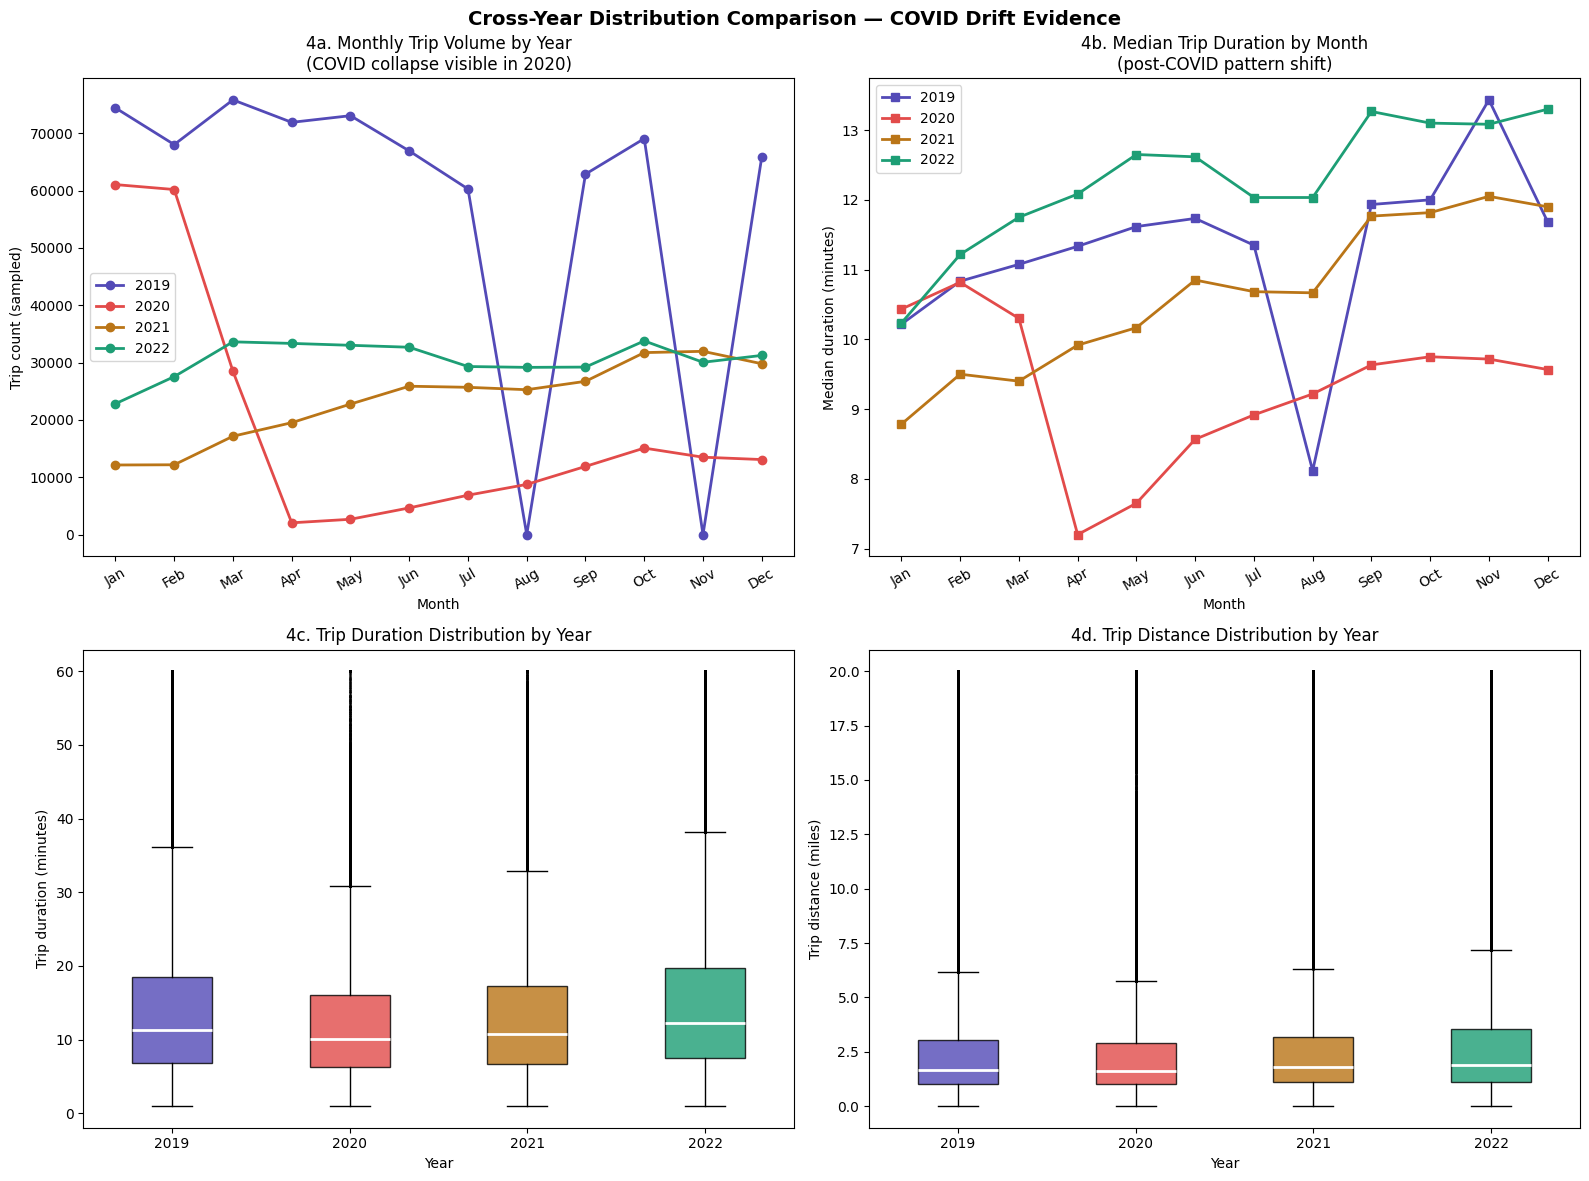

✓ Saved: cross_year_comparison.png


In [20]:
# ── SECTION 4: Cross-year visualisation ───────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Cross-Year Distribution Comparison — COVID Drift Evidence",
             fontsize=14, fontweight="bold")

colors = {2019:"#534AB7", 2020:"#E24B4A", 2021:"#BA7517", 2022:"#1D9E75"}
year_labels = [2019, 2020, 2021, 2022]

# 4a — Monthly trip volume across years
ax = axes[0, 0]
for yr in year_labels:
    subset = df_all[df_all["year"] == yr]
    monthly = subset.groupby("pickup_month").size()
    ax.plot(monthly.index, monthly.values,
            marker="o", color=colors[yr], label=str(yr), linewidth=2)
ax.set_title("4a. Monthly Trip Volume by Year\n(COVID collapse visible in 2020)")
ax.set_xlabel("Month")
ax.set_ylabel("Trip count (sampled)")
ax.legend()
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=30)

# 4b — Median trip duration by month across years
ax = axes[0, 1]
for yr in year_labels:
    subset = df_all[df_all["year"] == yr]
    monthly_dur = subset.groupby("pickup_month")[TARGET].median()
    ax.plot(monthly_dur.index, monthly_dur.values,
            marker="s", color=colors[yr], label=str(yr), linewidth=2)
ax.set_title("4b. Median Trip Duration by Month\n(post-COVID pattern shift)")
ax.set_xlabel("Month")
ax.set_ylabel("Median duration (minutes)")
ax.legend()
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=30)

# 4c — Trip duration distribution by year (box plot)
ax = axes[1, 0]
data_by_year = [df_all[df_all["year"] == yr][TARGET].clip(0, 60).values
                for yr in year_labels]
bp = ax.boxplot(data_by_year, labels=[str(y) for y in year_labels],
                patch_artist=True,
                medianprops=dict(color="white", linewidth=2),
                flierprops=dict(marker=".", markersize=1, alpha=0.2))
for patch, yr in zip(bp["boxes"], year_labels):
    patch.set_facecolor(colors[yr])
    patch.set_alpha(0.8)
ax.set_title("4c. Trip Duration Distribution by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Trip duration (minutes)")

# 4d — Trip distance distribution by year
ax = axes[1, 1]
data_dist = [df_all[df_all["year"] == yr]["trip_distance"].clip(0, 20).values
             for yr in year_labels]
bp2 = ax.boxplot(data_dist, labels=[str(y) for y in year_labels],
                 patch_artist=True,
                 medianprops=dict(color="white", linewidth=2),
                 flierprops=dict(marker=".", markersize=1, alpha=0.2))
for patch, yr in zip(bp2["boxes"], year_labels):
    patch.set_facecolor(colors[yr])
    patch.set_alpha(0.8)
ax.set_title("4d. Trip Distance Distribution by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Trip distance (miles)")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "cross_year_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: cross_year_comparison.png")

In [22]:
# ── Retrain frozen models on final 14 features ─────────────────────────

df_2019 = pd.read_parquet(os.path.join(SAVE_PATH, "df_2019_features.parquet"))

X_2019 = df_2019[FEATURES_FINAL]
y_2019 = df_2019[TARGET]

# Retrain Linear Regression
lr_frozen = LinearRegression()
lr_frozen.fit(X_2019, y_2019)

# Retrain XGBoost
xgb_frozen = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_frozen.fit(X_2019, y_2019)

# Overwrite saved models
with open(os.path.join(SAVE_PATH, "lr_2019_baseline.pkl"),  "wb") as f:
    pickle.dump(lr_frozen, f)
with open(os.path.join(SAVE_PATH, "xgb_2019_baseline.pkl"), "wb") as f:
    pickle.dump(xgb_frozen, f)

print(f"✓ Retrained on {len(X_2019):,} rows with {len(FEATURES_FINAL)} features")
print(f"  Features: {FEATURES_FINAL}")
print("✓ Models saved — now run Section 5 again")

✓ Retrained on 688,382 rows with 14 features
  Features: ['trip_distance', 'is_airport_trip', 'is_night', 'do_zone_type_enc', 'same_zone', 'PULocationID', 'DOLocationID', 'pickup_hour', 'is_rush_hour', 'pickup_month', 'pickup_dow', 'is_weekend', 'rate_type_enc', 'pu_zone_type_enc']
✓ Models saved — now run Section 5 again


In [23]:
# ── SECTION 5: Frozen 2019 model on 2020-2022 ─────────────────────────
# Load saved 2019 models and evaluate monthly on each year
# This shows performance DEGRADATION over time = concept drift evidence

with open(os.path.join(SAVE_PATH, "lr_2019_baseline.pkl"),  "rb") as f:
    lr_frozen = pickle.load(f)
with open(os.path.join(SAVE_PATH, "xgb_2019_baseline.pkl"), "rb") as f:
    xgb_frozen = pickle.load(f)

print("Loaded frozen 2019 models")

def evaluate_frozen(df_year, year_label, lr_model, xgb_model):
    results = []
    for month in sorted(df_year["pickup_month"].unique()):
        subset = df_year[df_year["pickup_month"] == month]

        # Use only features available in frozen model
        # Align to original 18 features if needed
        available = [f for f in FEATURES_FINAL if f in subset.columns]
        X_test = subset[available]
        y_test = subset[TARGET]

        if len(y_test) < 10:
            continue  # skip months with too few records

        lr_preds  = lr_model.predict(X_test)
        xgb_preds = xgb_model.predict(X_test)

        results.append({
            "year":      year_label,
            "month":     month,
            "period":    f"{year_label}-{month:02d}",
            "n_trips":   len(y_test),
            "lr_mae":    round(mean_absolute_error(y_test, lr_preds), 4),
            "lr_rmse":   round(np.sqrt(mean_squared_error(y_test, lr_preds)), 4),
            "lr_mape":   round(np.mean(np.abs((y_test - lr_preds) / y_test)) * 100, 4),
            "xgb_mae":   round(mean_absolute_error(y_test, xgb_preds), 4),
            "xgb_rmse":  round(np.sqrt(mean_squared_error(y_test, xgb_preds)), 4),
            "xgb_mape":  round(np.mean(np.abs((y_test - xgb_preds) / y_test)) * 100, 4),
        })
    return pd.DataFrame(results)

drift_2020 = evaluate_frozen(df_2020, 2020, lr_frozen, xgb_frozen)
drift_2021 = evaluate_frozen(df_2021, 2021, lr_frozen, xgb_frozen)
drift_2022 = evaluate_frozen(df_2022, 2022, lr_frozen, xgb_frozen)

drift_all = pd.concat([drift_2020, drift_2021, drift_2022]).reset_index(drop=True)
print(drift_all[["period","n_trips","lr_mae","xgb_mae","xgb_mape"]].to_string(index=False))

Loaded frozen 2019 models
 period  n_trips  lr_mae  xgb_mae  xgb_mape
2020-01    61061  5.5186   3.0909   28.7797
2020-02    60200  5.8691   3.0091   26.9018
2020-03    28472  5.2567   3.1915   31.8053
2020-04     2057  2.7371   5.1814   69.5359
2020-05     2676  2.7953   5.1185   65.3005
2020-06     4657  3.3227   4.8792   59.2680
2020-07     6876  3.3502   4.1270   48.2348
2020-08     8757  3.5718   4.4200   51.8307
2020-09    11895  3.7342   4.1051   47.4021
2020-10    15096  3.8750   3.7503   42.2149
2020-11    13505  3.7543   3.8711   43.8160
2020-12    13094  3.7113   4.0696   46.5590
2021-01    12145  3.7189   3.0678   37.0437
2021-02    12182  4.3142   3.1847   34.7402
2021-03    17163  4.0727   3.3205   37.7185
2021-04    19527  4.3834   3.4495   36.7381
2021-05    22771  4.5654   3.5169   36.9105
2021-06    25887  5.0304   3.6427   36.2579
2021-07    25697  4.5299   3.4753   33.1429
2021-08    25277  4.3214   3.9593   39.6496
2021-09    26741  5.3433   3.8405   34.3008
2021-1

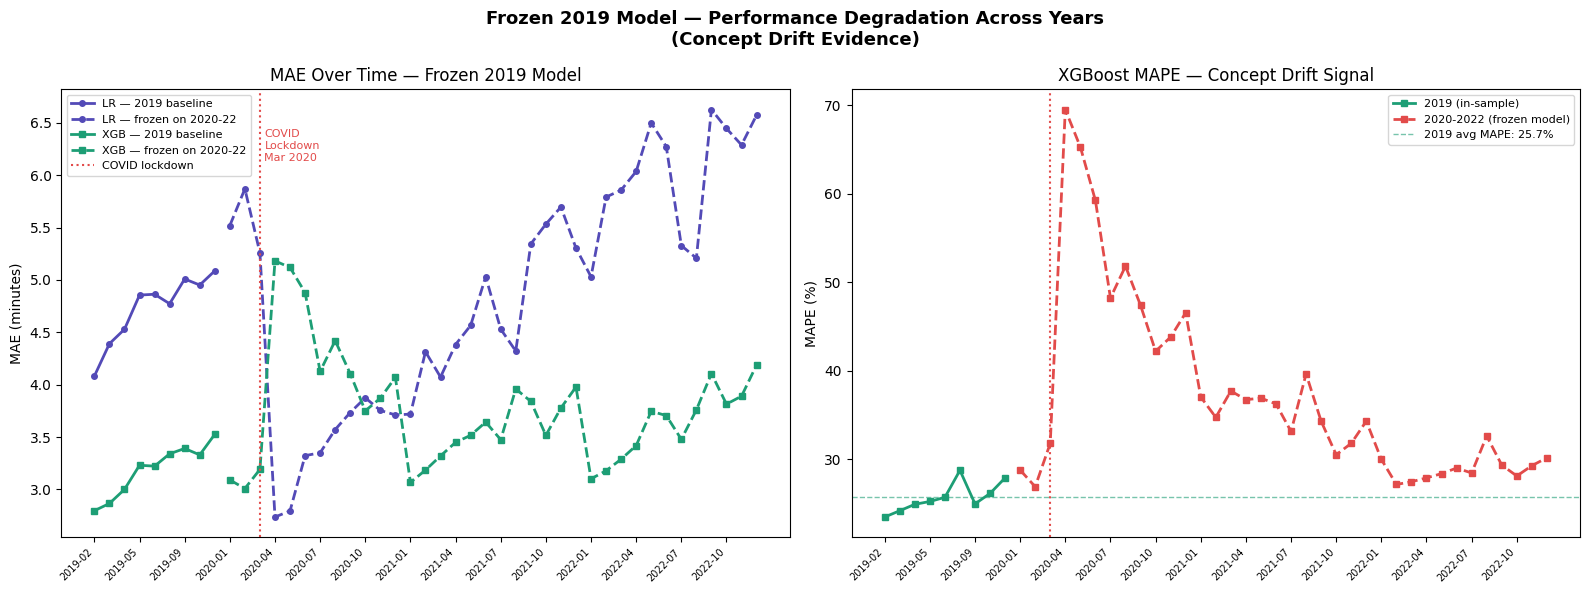

✓ Saved: drift_evidence.png


In [24]:
# ── SECTION 6: Drift visualisation ────────────────────────────────────

# Also load 2019 baseline results for comparison
results_2019 = pd.read_parquet(os.path.join(SAVE_PATH, "walk_forward_results_2019.parquet"))
results_2019["period"] = results_2019["test_month"].apply(lambda m: f"2019-{m:02d}")
results_2019["year"]   = 2019

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Frozen 2019 Model — Performance Degradation Across Years\n(Concept Drift Evidence)",
             fontsize=13, fontweight="bold")

# Filter out anomaly months from 2019 (Aug=1 record, Nov=4 records)
results_2019_clean = results_2019[results_2019["test_size"] > 100]

# Build combined timeline
all_periods_lr  = list(results_2019_clean["lr_mae"])  + list(drift_all["lr_mae"])
all_periods_xgb = list(results_2019_clean["xgb_mae"]) + list(drift_all["xgb_mae"])
all_labels      = list(results_2019_clean["period"])  + list(drift_all["period"])

x = range(len(all_labels))

# MAE over time
ax = axes[0]
ax.plot(x[:len(results_2019_clean)], all_periods_lr[:len(results_2019_clean)],
        color="#534AB7", marker="o", markersize=4, label="LR — 2019 baseline", linewidth=2)
ax.plot(x[len(results_2019_clean):], all_periods_lr[len(results_2019_clean):],
        color="#534AB7", marker="o", markersize=4, linestyle="--", label="LR — frozen on 2020-22", linewidth=2)
ax.plot(x[:len(results_2019_clean)], all_periods_xgb[:len(results_2019_clean)],
        color="#1D9E75", marker="s", markersize=4, label="XGB — 2019 baseline", linewidth=2)
ax.plot(x[len(results_2019_clean):], all_periods_xgb[len(results_2019_clean):],
        color="#1D9E75", marker="s", markersize=4, linestyle="--", label="XGB — frozen on 2020-22", linewidth=2)

# COVID annotation
covid_x = len(results_2019_clean) + 2  # approx March 2020
ax.axvline(covid_x, color="#E24B4A", linewidth=1.5, linestyle=":", label="COVID lockdown")
ax.text(covid_x + 0.3, ax.get_ylim()[1] * 0.9, "COVID\nLockdown\nMar 2020",
        fontsize=8, color="#E24B4A")

ax.set_title("MAE Over Time — Frozen 2019 Model")
ax.set_ylabel("MAE (minutes)")
ax.set_xticks(list(x)[::3])
ax.set_xticklabels(all_labels[::3], rotation=45, ha="right", fontsize=7)
ax.legend(fontsize=8)

# XGB MAPE only (cleaner view)
ax = axes[1]
xgb_mape_2019 = list(results_2019_clean["xgb_mape"])
xgb_mape_post = list(drift_all["xgb_mape"])
all_mape = xgb_mape_2019 + xgb_mape_post

ax.plot(x[:len(results_2019_clean)], xgb_mape_2019,
        color="#1D9E75", marker="s", markersize=4, label="2019 (in-sample)", linewidth=2)
ax.plot(x[len(results_2019_clean):], xgb_mape_post,
        color="#E24B4A", marker="s", markersize=4, linestyle="--",
        label="2020-2022 (frozen model)", linewidth=2)
ax.axvline(covid_x, color="#E24B4A", linewidth=1.5, linestyle=":")
ax.axhline(np.mean(xgb_mape_2019), color="#1D9E75", linewidth=1,
           linestyle="--", alpha=0.6, label=f"2019 avg MAPE: {np.mean(xgb_mape_2019):.1f}%")
ax.set_title("XGBoost MAPE — Concept Drift Signal")
ax.set_ylabel("MAPE (%)")
ax.set_xticks(list(x)[::3])
ax.set_xticklabels(all_labels[::3], rotation=45, ha="right", fontsize=7)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "drift_evidence.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: drift_evidence.png")